In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df_netflix = pd.read_csv("data/datos_netflix.csv")

In [4]:
#### parte exploratoria ####
print(f"Esto tiene: {df_netflix.shape[0]} filas y {df_netflix.shape[1]} columnas")
print (f"Tiene un total de: {df_netflix.isna().sum().values.sum()} valores nulos")

Esto tiene: 4812 filas y 11 columnas
Tiene un total de: 0 valores nulos


In [5]:
### eliminamos columnas ###
df_netflix_1 = df_netflix.drop(columns=['description','show_id'])
df_netflix_1

,type,title,director,cast,country,date_added,release_year,duration,genre
0,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,93,Dramas
1,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,78,Horror Movies
2,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,80,Action
3,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,123,Dramas
4,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,"July 1, 2017",2016,1,International TV
...,...,...,...,...,...,...,...,...,...
4807,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,88,Comedies
4808,Movie,Zoo,Shlok Sharma,"Shashank Arora, Shweta Tripathi, Rahul Kumar, ...",India,"July 1, 2018",2018,94,Dramas
4809,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,88,Children
4810,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...",Sweden,"October 19, 2020",2005,99,Dramas


In [6]:
# remplazo --> # > title #
df_netflix_2 = df_netflix_1.replace('[#]','',regex=True)
df_netflix_2

,type,title,director,cast,country,date_added,release_year,duration,genre
0,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,93,Dramas
1,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,78,Horror Movies
2,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,80,Action
3,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,123,Dramas
4,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,"July 1, 2017",2016,1,International TV
...,...,...,...,...,...,...,...,...,...
4807,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,88,Comedies
4808,Movie,Zoo,Shlok Sharma,"Shashank Arora, Shweta Tripathi, Rahul Kumar, ...",India,"July 1, 2018",2018,94,Dramas
4809,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,88,Children
4810,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...",Sweden,"October 19, 2020",2005,99,Dramas


In [7]:
## modificamos la columna fecha ##

df_netflix_2['date_added'] = pd.to_datetime(df_netflix_2['date_added'], format='mixed', errors='coerce') 
df_netflix_2['date_added'] = pd.to_datetime(df_netflix_2['date_added'], format='%Y-%m-%d')
df_netflix_2['date_added_year'] = df_netflix_2['date_added'].dt.year 

In [8]:
## 1º duración más frecuente de las películas entre 1990 y 1999 #
df_netflix_2_90s = df_netflix_2[(df_netflix_2['release_year']>=1990)&(df_netflix_2['release_year']<=1999)]
duration_90s = df_netflix_2_90s['duration'].mode()[0] 

print(f"La duración más frecuente de las películas entre 1990 y 1999 es: {duration_90s} minutos")

La duración más frecuente de las películas entre 1990 y 1999 es: 94 minutos


In [9]:
## 2º número total de películas de acción que duran menos de 90 minutos entre 1990 y 1999 #
pel_accion_menos90 = df_netflix_2_90s[(df_netflix_2_90s['genre'].str.contains('Action', case=False)) & (df_netflix_2_90s['duration'] < 90)]
t_pel_accion_menos90 = pel_accion_menos90.shape[0] 
print(f"El número total de películas de acción que duran menos de 90 minutos entre 1990 y 1999 es: {t_pel_accion_menos90} peliculas")

El número total de películas de acción que duran menos de 90 minutos entre 1990 y 1999 es: 7 peliculas


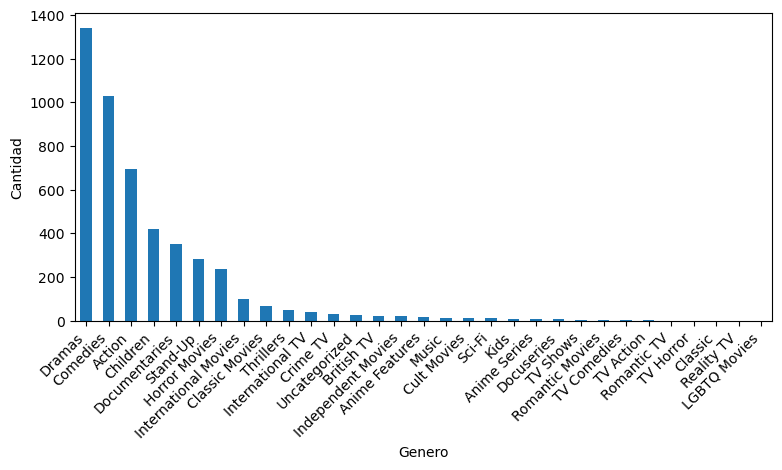

In [10]:
## 1º grafico de barras: nº total de peliculas x genero ##
total_genero = df_netflix_2['genre'].value_counts() 
plt.figure(figsize=(9, 4))  
total_genero.plot(kind='bar')
plt.xlabel('Genero')
plt.xticks(rotation=45, ha="right") 
plt.ylabel('Cantidad')
plt.show()

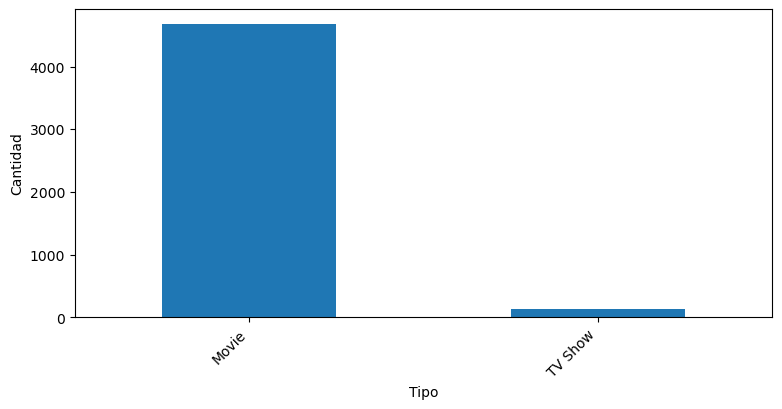

In [11]:
## 2º grafico de barras: nº total de filmografias x tipo
total_tipo = df_netflix_2['type'].value_counts()
plt.figure(figsize=(9, 4))
total_tipo.plot(kind='bar')
plt.xlabel('Tipo')
plt.xticks(rotation=45, ha="right") 
plt.ylabel('Cantidad')
plt.show()

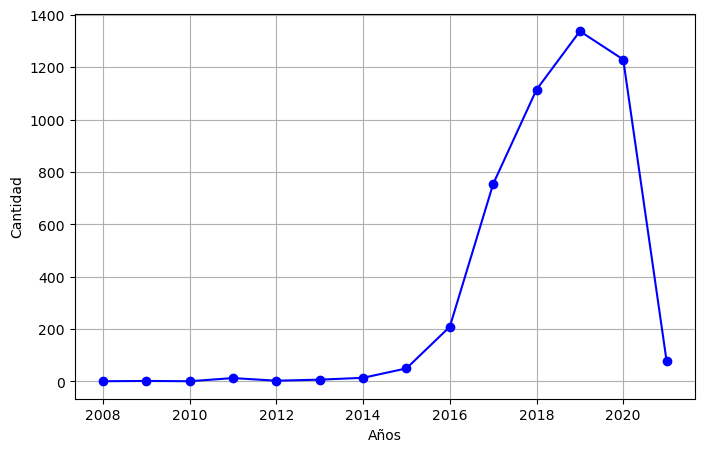

In [12]:
##3º grafico lineal: cantidad de filmografias x año
filmografia = df_netflix_2['date_added_year'].value_counts().sort_index() # hemos calculado la cantidad de veces que aparece ese año en el dataframe.
plt.figure(figsize=(8, 5)) #dimensiones del grafico lineal
plt.plot(filmografia.index, filmografia.values, marker='o', linestyle='-', color='b') # creación del grafico líneal con plot (marker = o => añade marcador)
plt.xlabel('Años') #titulo al eje X
plt.ylabel('Cantidad') #titulo al eje y
plt.grid(True) #añade formato cuadricula.
plt.show()